# ISM 6564 — Assignment 1

## A Tokenization Report

**Week 1 — Text as Data & Tokenization**

You are on the data platform team at an online retailer that also runs a large
public community forum. Three projects are blocked on one unmeasured decision:
how will we tokenize?

- **Project A — Lexical search.** An inverted index over the forum archive.
- **Project B — Thread summarization** through a frontier LLM API. Finance
  wants a cost number.
- **Project C — International rollout** to four more language markets on the same
  paid plan.

Work through Tasks 1–6. Read `README.md` first — it has the full task
descriptions, the deliverables, and the rubric. This notebook gives you the
data, the helpers, and the places to write your answers.

**Two rules that decide most of your mark:**

1. Every number you state in prose must be produced by a visible cell above it.
2. Run the whole notebook top to bottom before you submit. Outputs must be
   visible in the file you upload.

---

## Setup

Run this cell first. It is complete — nothing to fill in.

In [1]:
import os
import random
import re
import sys
import unicodedata
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch

# Portable device selection: CUDA, else Apple Silicon MPS, else CPU.
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

SEED = 6564
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print(f"python      {sys.version.split()[0]}")
print(f"torch       {torch.__version__}  (device: {device})")
print(f"pandas      {pd.__version__}")
print(f"numpy       {np.__version__}")

python      3.12.10
torch       2.11.0+cpu  (device: cpu)
pandas      3.0.2
numpy       2.4.4


In [2]:
# Tokenizer libraries. All are already in the course environment.
import nltk
import tiktoken
from transformers import AutoTokenizer

# nltk.word_tokenize needs the Punkt sentence model. Downloaded once, cached.
for pkg in ("punkt", "punkt_tab"):
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, quiet=True)

print("nltk       ", nltk.__version__)
print("tiktoken   ", tiktoken.__version__)
import transformers
print("transformers", transformers.__version__)

nltk        3.9.4
tiktoken    0.12.0
transformers 5.7.0


In [3]:
def todo(message):
    """Print a clear reminder instead of crashing on an unfinished TODO.

    Every task cell below starts with its answer variable set to None. Until
    you replace it, the cell prints this reminder and moves on, so the
    notebook always runs top to bottom.
    """
    print(f"[ TODO ]  {message}")


def show(obj, title=None):
    """Display a DataFrame or print anything else, with an optional heading."""
    if title:
        print(f"\n=== {title} ===")
    try:
        from IPython.display import display
        display(obj)
    except Exception:
        print(obj)

### The corpus

`load_corpus()` fetches four newsgroups from the 20 Newsgroups collection and
returns them as `(archive, holdout)`:

- **archive** — the train split. This is "the forum as it exists today". Every
  vocabulary you build comes from here.
- **holdout** — the test split. This is "next month's posts". You never fit
  anything on it; you only measure against it.

Headers and footers are stripped. Quoted reply text, signatures, e-mail
addresses, and URLs are **kept on purpose** — that surface noise is the whole
reason tokenization decisions matter.

scikit-learn downloads the collection once (~14 MB) and caches it in
`~/scikit_learn_data/`. After the first run you are offline.

In [4]:
from sklearn.datasets import fetch_20newsgroups

CATEGORIES = ["comp.sys.mac.hardware", "rec.sport.baseball", "sci.med", "sci.space"]


def load_corpus():
    """Return (archive_docs, holdout_docs) as lists of strings. Do not change."""
    kw = dict(categories=CATEGORIES, remove=("headers", "footers"),
              random_state=0, shuffle=False)
    archive = fetch_20newsgroups(subset="train", **kw).data
    holdout = fetch_20newsgroups(subset="test", **kw).data
    return archive, holdout


archive, holdout = load_corpus()

print(f"archive : {len(archive):>5,} documents  {sum(map(len, archive)):>10,} characters")
print(f"holdout : {len(holdout):>5,} documents  {sum(map(len, holdout)):>10,} characters")
print("\n--- a sample document ---")
print(archive[7][:600])

archive : 2,362 documents   3,133,653 characters
holdout : 1,572 documents   2,095,598 characters

--- a sample document ---
In article <1993Apr15.131954.1@fnalf.fnal.gov> higgins@fnalf.fnal.gov (Bill Higgins-- Beam Jockey) writes:

>Reid, alas, gives us no measure of the "power/influence" of readers...
>Sorry, Mark.

I think I can. Largely as a result of efforts by people reading this group
writing letters and making phone calls the following has happened:

1. NASA reprogrammed funds to keep NASP alive in 1991.
2. Efforts to kill DC-X and the SSRT progam where twice twarted
   (Feb. and June of last year).
3. Gouldin kept his job in spite of heavy lobbying against him.

This may not be what Mark was thinking of but


### The parallel multilingual corpus

`data/udhr_parallel.json` holds the Universal Declaration of Human Rights in
five languages: English, German, Spanish, Hindi, and Chinese (Simplified).
Every entry says **the same thing**, so any difference in token count is a
property of the tokenizer, not of the content. That is what makes it usable as
evidence rather than as illustration.

The five span the axes that matter here: Latin-script analytic (English),
Latin-script compounding (German), Latin-script inflecting (Spanish), a
Devanagari abugida (Hindi), and a logographic script with no whitespace word
boundaries (Chinese). Provenance is in `../data/README.md`.

In [5]:
import json
from urllib.request import urlopen

PARALLEL_URL = (
    "https://raw.githubusercontent.com/prof-tcsmith/6564F26-DATA/main/"
    "week-01-text-tokenization/data/udhr_parallel.json"
)
PARALLEL_LOCAL = [
    Path("../data/udhr_parallel.json"),
    Path("week-01-text-tokenization/data/udhr_parallel.json"),
    Path("data/udhr_parallel.json"),
]


def load_parallel():
    """Local first so a clone works offline; URL fallback so Colab works."""
    raw = None
    for p in PARALLEL_LOCAL:
        if p.exists():
            raw = json.loads(p.read_text(encoding="utf-8"))
            break
    if raw is None:
        raw = json.loads(urlopen(PARALLEL_URL).read().decode("utf-8"))
    return pd.DataFrame([
        {"language": name, "code": d["code"], "script": d["script"],
         "n_chars": len(d["text"]), "text": d["text"]}
        for name, d in raw.items()
    ])


parallel = load_parallel()
show(parallel[["language", "code", "script", "n_chars"]], "parallel corpus")
print("\nEnglish, first 200 characters:")
print(parallel.loc[parallel.language == "English", "text"].iloc[0][:200])


=== parallel corpus ===


,language,code,script,n_chars
0,English,eng,Latin,10637
1,German,deu,Latin,11936
2,Spanish,spa,Latin,11964
3,Hindi,hin,Devanagari,11463
4,Chinese (Simplified),cmn-Hans,Han (Simplified),2988



English, first 200 characters:
Universal Declaration of Human Rights
Preamble
Whereas recognition of the inherent dignity and of the equal and inalienable rights of all members of the human family is the foundation of freedom, just


### The stress set and the rate card

`STRESS_SET` is eight short strings chosen to break things. `RATE_CARD` is an
**illustrative** price list in US dollars per million tokens — it is a stated
assumption of your analysis, not a quote from any vendor. Frontier pricing
changes often; if you use different numbers, say so and cite where they came
from.

In [6]:
STRESS_SET = [
    "Refund my order 😤 please",
    "café résumé naïve",
    "日本語のテキストです",
    "मानव अधिकारों की घोषणा",
    "Ωmega ΔV = 9.4 km/s",
    "₹1,299 refunded to ****4417",
    "https://forum.example.com/t/LC-475-won't-boot?ref=email",
    "🚀🛰️",
]

# Illustrative rate card: US dollars per 1,000,000 tokens.
RATE_CARD = {
    "input_per_mtok": 2.50,
    "output_per_mtok": 10.00,
}

for s in STRESS_SET:
    print(f"{len(s):>3} chars  {s}")
print()
print("RATE_CARD:", RATE_CARD)

 24 chars  Refund my order 😤 please
 17 chars  café résumé naïve
 10 chars  日本語のテキストです
 22 chars  मानव अधिकारों की घोषणा
 19 chars  Ωmega ΔV = 9.4 km/s
 27 chars  ₹1,299 refunded to ****4417
 55 chars  https://forum.example.com/t/LC-475-won't-boot?ref=email
  3 chars  🚀🛰️

RATE_CARD: {'input_per_mtok': 2.5, 'output_per_mtok': 10.0}


---

# Task 1 — Baseline: how many words are there?

Tokenize the **archive** three ways and compare. Then find three places where
whitespace splitting produces something that is not a word.

Full description and deliverables: `README.md`, Task 1.

In [7]:
# ---------------------------------------------------------------- Task 1a
# A regex tokenizer.
#
# It should keep words (including internal apostrophes and hyphens) and keep
# standalone punctuation out of the token stream. There is no single right
# answer -- make a defensible choice and be ready to defend it.
#
# Design: a token is a run of alphanumerics, optionally continued by a single
# apostrophe or hyphen followed by more alphanumerics ("won't", "LC-475").
# A lone "-" or "'" (not glued to letters/digits on both sides) is dropped,
# same as any other standalone punctuation. This tokenizer is not URL-aware
# on purpose -- see Task 1d.

_TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:['-][A-Za-z0-9]+)*")


def regex_tokenize(text):
    """Tokenize `text` with a regular expression and return a list."""
    return _TOKEN_RE.findall(text)


_probe = regex_tokenize("Don't ship the LC-475 -- it won't boot! see http://a.io/x")
if _probe is None:
    todo("Task 1a - implement regex_tokenize()")
else:
    print(_probe)

["Don't", 'ship', 'the', 'LC-475', 'it', "won't", 'boot', 'see', 'http', 'a', 'io', 'x']


In [8]:
# ---------------------------------------------------------------- Task 1b
# Build the comparison table.
#
# For each of the three tokenizers -- str.split, regex_tokenize,
# nltk.word_tokenize -- run it over every document in `archive` and report:
#
#   tokenizer | n_tokens | n_types | type_token_ratio | mean_tokens_per_doc
#
# Store the token STREAMS too; Task 2 and Task 3 both reuse the whitespace one.
# nltk.word_tokenize over ~2,400 documents takes a second or two.

def _flatten(tokenize_fn, docs):
    """Tokenize every document and concatenate the results, in document order."""
    stream = []
    for doc in docs:
        stream.extend(tokenize_fn(doc))
    return stream


streams = {
    "whitespace": _flatten(str.split, archive),
    "regex": _flatten(regex_tokenize, archive),
    "nltk": _flatten(nltk.word_tokenize, archive),
}

n_docs = len(archive)
rows = []
for name, stream in streams.items():
    n_tokens = len(stream)
    n_types = len(set(stream))
    rows.append({
        "tokenizer": name,
        "n_tokens": n_tokens,
        "n_types": n_types,
        "type_token_ratio": n_types / n_tokens,
        "mean_tokens_per_doc": n_tokens / n_docs,
    })

task1_table = pd.DataFrame(rows)

if streams is None or task1_table is None:
    todo("Task 1b - build `streams` and `task1_table`")
else:
    show(task1_table, "Task 1 - tokenizer comparison")


=== Task 1 - tokenizer comparison ===


,tokenizer,n_tokens,n_types,type_token_ratio,mean_tokens_per_doc
0,whitespace,501321,67367,0.134379,212.244285
1,regex,513526,40694,0.079244,217.411516
2,nltk,632239,42994,0.068003,267.671041


In [9]:
# ---------------------------------------------------------------- Task 1c
# The 15 most frequent types for each tokenizer.
#
# Put them side by side so the differences are visible at a glance.

N_TOP = 15

top15_columns = {}
for name, stream in streams.items():
    counts = Counter(stream)
    top15_columns[name] = [f"{tok} ({n:,})" for tok, n in counts.most_common(N_TOP)]

task1_top15 = pd.DataFrame(top15_columns)
task1_top15.index = range(1, N_TOP + 1)
task1_top15.index.name = "rank"

if task1_top15 is None:
    todo("Task 1c - build `task1_top15`")
else:
    show(task1_top15, "Task 1 - 15 most frequent types")


=== Task 1 - 15 most frequent types ===


,whitespace,regex,nltk
rank,,,
1,"the (20,895)","the (21,228)",". (23,823)"
2,"to (11,027)","to (11,238)",", (23,602)"
3,"of (10,302)","a (10,458)","the (21,214)"
4,"a (10,266)","of (10,455)","> (18,606)"
5,"and (9,098)","and (9,428)","-- (11,418)"
6,"in (6,519)","is (6,769)","to (11,234)"
7,"is (6,475)","in (6,717)","of (10,450)"
8,"I (6,111)","I (6,702)","a (10,419)"
9,"that (5,274)","that (5,560)","and (9,392)"


In [10]:
# ---------------------------------------------------------------- Task 1d
# Find three real failure cases IN THE CORPUS.
#
#   1. a URL or an e-mail address,
#   2. a piece of punctuation-glued text (e.g. `word,another` or `>quoted`),
#   3. one more of your choosing.
#
# For each: print the original substring, then what all three tokenizers do
# with it. Search `archive` -- do not invent the strings.

def _first_whitespace_token(pattern, tokens):
    """Return the first str.split() token matching `pattern`, in document order."""
    rx = re.compile(pattern)
    for tok in tokens:
        if rx.search(tok):
            return tok
    return None


# Reuse streams["whitespace"] from Task 1b: it is str.split() applied to every
# document in `archive`, concatenated in document order, so searching it is
# searching the corpus -- nothing here is invented.
email_case = _first_whitespace_token(
    r"^[\w.+-]+@[\w-]+\.[\w.-]+$", streams["whitespace"])
punct_glued_case = _first_whitespace_token(
    r"^[A-Za-z]+[,;:][A-Za-z]+$", streams["whitespace"])
emoticon_case = _first_whitespace_token(
    r"^[:;]-?[)(DPp]$", streams["whitespace"])

failure_cases = [email_case, punct_glued_case, emoticon_case]

if failure_cases is None:
    todo("Task 1d - find three failure cases in `archive` and show all three tokenizations")
else:
    for s in failure_cases:
        print(repr(s))
        print("   split :", s.split())
        print("   regex :", regex_tokenize(s))
        print("   nltk  :", nltk.word_tokenize(s))
        print()

'gajarsky@pilot.njin.net'
   split : ['gajarsky@pilot.njin.net']
   regex : ['gajarsky', 'pilot', 'njin', 'net']
   nltk  : ['gajarsky', '@', 'pilot.njin.net']

'steroids,his'
   split : ['steroids,his']
   regex : ['steroids', 'his']
   nltk  : ['steroids', ',', 'his']

';-)'
   split : [';-)']
   regex : []
   nltk  : [';', '-', ')']



### Task 1 — write-up

**TODO (≤150 words).** Which of the differences you just showed would change a
lexical search index, and which are cosmetic? Be concrete: name a query that
would succeed under one tokenizer and fail under another.

*Some differences are that regex split the email address into four tokens which would make it not possible to search as a single term, since it treats it as four different terms. nltk keeps the domain part so pilot.njin.net so that is better for search. A cosmetic change is that regex does not pick up punctuation, so it does not pick up periods, @, commas, or any of ;-), for  the first two examples that is purely cosmetic, but for the last example that is also a search issue.*

---

# Task 2 — Vocabulary growth

Walk the archive in document order. Every 25,000 tokens, record how many
tokens you have seen and how many **distinct** types you have seen, for three
tokenizers: whitespace, `bert-base-uncased`, and `gpt2`.

Then fit Heaps' law to the whitespace curve:

$$V = k N^{\beta} \qquad\Longleftrightarrow\qquad \log V = \log k + \beta \log N$$

That second form is an ordinary least-squares line fit, which you have done
many times. `np.polyfit(log_N, log_V, 1)` returns $(\beta, \log k)$.

Full description and deliverables: `README.md`, Task 2.

In [11]:
# Loading the two Hugging Face tokenizers. Complete -- nothing to fill in.
# The first call downloads a few hundred KB and caches it in ~/.cache/huggingface.

bert_tok = AutoTokenizer.from_pretrained("bert-base-uncased")
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")

print(f"bert-base-uncased  vocab_size={bert_tok.vocab_size:,}  unk={bert_tok.unk_token!r}")
print(f"gpt2               vocab_size={gpt2_tok.vocab_size:,}  unk={gpt2_tok.unk_token!r}")
print()
sample = "The LC-475 won't boot after the 7.5.3 update — café included."
print("bert:", bert_tok.tokenize(sample))
print("gpt2:", gpt2_tok.tokenize(sample))

bert-base-uncased  vocab_size=30,522  unk='[UNK]'
gpt2               vocab_size=50,257  unk='<|endoftext|>'

bert: ['the', 'lc', '-', '475', 'won', "'", 't', 'boot', 'after', 'the', '7', '.', '5', '.', '3', 'update', '—', 'cafe', 'included', '.']
gpt2: ['The', 'ĠLC', '-', '475', 'Ġwon', "'t", 'Ġboot', 'Ġafter', 'Ġthe', 'Ġ7', '.', '5', '.', '3', 'Ġupdate', 'ĠâĢĶ', 'ĠcafÃ©', 'Ġincluded', '.']


In [12]:
# ---------------------------------------------------------------- Task 2a
# Build the three token streams over the archive, in document order.
#
# Whitespace: reuse `streams["whitespace"]` from Task 1.
# BERT / GPT-2: call the tokenizer on the whole list of documents at once and
#   flatten the result, e.g.
#       ids = bert_tok(archive, add_special_tokens=False)["input_ids"]
#   Passing add_special_tokens=False matters: [CLS]/[SEP] are not corpus
#   content and would inflate your counts by two per document.
#
# You may see a warning that a sequence is longer than the model maximum.
# That is about running the MODEL, not the tokenizer. It is safe here.

bert_ids = bert_tok(archive, add_special_tokens=False)["input_ids"]
gpt2_ids = gpt2_tok(archive, add_special_tokens=False)["input_ids"]

growth_streams = {
    "whitespace": streams["whitespace"],
    "bert": [tok_id for doc_ids in bert_ids for tok_id in doc_ids],
    "gpt2": [tok_id for doc_ids in gpt2_ids for tok_id in doc_ids],
}

if growth_streams is None:
    todo("Task 2a - build `growth_streams`")
else:
    for k, v in growth_streams.items():
        print(f"{k:<12} {len(v):>9,} tokens   {len(set(v)):>7,} distinct")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1107 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1177 > 1024). Running this sequence through the model will result in indexing errors


whitespace     501,321 tokens    67,367 distinct
bert           791,486 tokens    17,500 distinct
gpt2           916,109 tokens    28,852 distinct


In [13]:
# ---------------------------------------------------------------- Task 2b
# The growth curves.
#
# Walk each stream once, adding to a set as you go. Every CHECKPOINT tokens,
# append (tokens_seen, distinct_so_far). Append the final point too, so the
# curve reaches the end of the stream.

CHECKPOINT = 25_000


def _growth_curve(tokens, checkpoint):
    """Walk `tokens` once; return (N, V) arrays checkpointed every `checkpoint` tokens."""
    seen = set()
    Ns, Vs = [], []
    for i, tok in enumerate(tokens, start=1):
        seen.add(tok)
        if i % checkpoint == 0:
            Ns.append(i)
            Vs.append(len(seen))
    if not Ns or Ns[-1] != len(tokens):
        Ns.append(len(tokens))
        Vs.append(len(seen))
    return np.array(Ns), np.array(Vs)


growth_curves = {
    name: _growth_curve(tokens, CHECKPOINT)
    for name, tokens in growth_streams.items()
}

if growth_curves is None:
    todo("Task 2b - build `growth_curves`")
else:
    for name, (N, V) in growth_curves.items():
        print(f"{name:<12} {len(N):>3} checkpoints   final N={N[-1]:>9,}   final V={V[-1]:>7,}")

whitespace    21 checkpoints   final N=  501,321   final V= 67,367
bert          32 checkpoints   final N=  791,486   final V= 17,500
gpt2          37 checkpoints   final N=  916,109   final V= 28,852


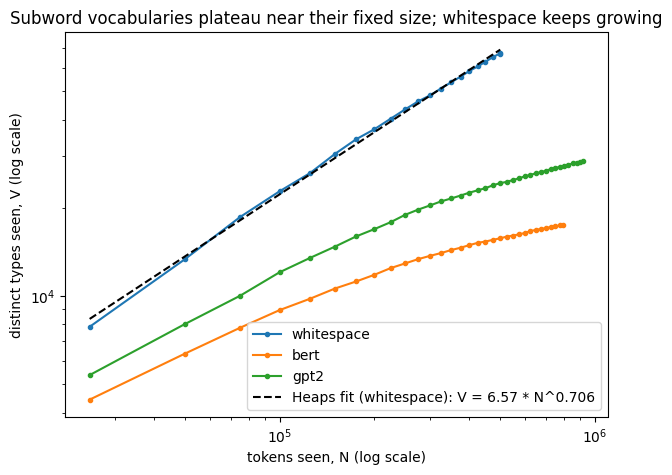

Heaps' law on the whitespace curve:  k = 6.565   beta = 0.7059


In [14]:
# ---------------------------------------------------------------- Task 2c
# Plot all three curves on log-log axes, and fit Heaps' law to the
# whitespace curve only.
#
# Report k and beta. Overlay the fitted line on the whitespace curve so a
# reader can see whether the fit is any good.

ws_N, ws_V = growth_curves["whitespace"]
log_N = np.log(ws_N)
log_V = np.log(ws_V)
heaps_beta, log_k = np.polyfit(log_N, log_V, 1)
heaps_k = np.exp(log_k)

fig, ax = plt.subplots(figsize=(7, 5))
for name, (N, V) in growth_curves.items():
    ax.loglog(N, V, marker="o", markersize=3, label=name)

fit_V = heaps_k * ws_N ** heaps_beta
ax.loglog(ws_N, fit_V, linestyle="--", color="black",
          label=f"Heaps fit (whitespace): V = {heaps_k:.2f} * N^{heaps_beta:.3f}")

ax.set_xlabel("tokens seen, N (log scale)")
ax.set_ylabel("distinct types seen, V (log scale)")
ax.set_title("Subword vocabularies plateau near their fixed size; whitespace keeps growing")
ax.legend()
plt.show()

if growth_curves is None:
    todo("Task 2c - needs `growth_curves` from 2b")
elif heaps_k is None:
    todo("Task 2c - fit Heaps' law and plot the three curves")
else:
    print(f"Heaps' law on the whitespace curve:  k = {heaps_k:.3f}   beta = {heaps_beta:.4f}")

### Task 2 — write-up

**TODO (≤150 words).** What do the two subword curves do that the whitespace
curve does not? Why is that a *design decision* rather than a property of the
corpus? Refer to your fitted $\beta$.

*BERT and GPT-2 plateau after a while, while whitespace keeps going up. This is a design decision because they are built from a fixed and closed vocabulary that when most of the vocabulary is seen in a corpus new documents will resuse existing vocabulary. Whitespace has an open ended vocabulary that is not capped.*

---

# Task 3 — Out of vocabulary

Three measurements that appear to contradict each other. Reconciling them is
the task.

Full description and deliverables: `README.md`, Task 3.

In [15]:
# ---------------------------------------------------------------- Task 3a
# Word-level OOV against the held-out split.
#
# Build a frequency table of whitespace types over the ARCHIVE. For each cap V
# in VOCAB_CAPS, keep the V most frequent types; then measure on HOLDOUT:
#
#   oov_token_rate = (# held-out token occurrences not in vocab) / (# held-out tokens)
#   oov_type_rate  = (# held-out distinct types not in vocab)    / (# held-out distinct types)
#
# Those two numbers are very different. That difference is worth a sentence.

VOCAB_CAPS = [2_000, 5_000, 10_000, 25_000, 50_000, None]  # None = keep everything

archive_counts = Counter(streams["whitespace"])
holdout_counts = Counter(_flatten(str.split, holdout))

n_holdout_tokens = sum(holdout_counts.values())
n_holdout_types = len(holdout_counts)

rows = []
for cap in VOCAB_CAPS:
    vocab = {tok for tok, _ in archive_counts.most_common(cap)}
    oov_token_count = sum(n for tok, n in holdout_counts.items() if tok not in vocab)
    oov_type_count = sum(1 for tok in holdout_counts if tok not in vocab)
    rows.append({
        "vocab_cap": cap if cap is not None else "all",
        "vocab_size": len(vocab),
        "oov_token_rate": oov_token_count / n_holdout_tokens,
        "oov_type_rate": oov_type_count / n_holdout_types,
    })

oov_table = pd.DataFrame(rows)

if oov_table is None:
    todo("Task 3a - build `oov_table`")
else:
    show(oov_table, "Task 3a - word-level OOV on held-out text")


=== Task 3a - word-level OOV on held-out text ===


,vocab_cap,vocab_size,oov_token_rate,oov_type_rate
0,2000,2000,0.333953,0.957983
1,5000,5000,0.254872,0.899235
2,10000,10000,0.202741,0.820602
3,25000,25000,0.153617,0.692857
4,50000,50000,0.127593,0.600055
5,all,67367,0.113678,0.547428


In [16]:
# ---------------------------------------------------------------- Task 3b
# How many [UNK] tokens do the subword tokenizers actually emit on the
# held-out split?
#
# Tokenize `holdout` with bert_tok and with gpt2_tok and count occurrences of
# each tokenizer's unk_token_id. Report the raw counts and the rates.
#
# Read the result before you write about it. It may not be what you expect.

bert_holdout_ids = bert_tok(holdout, add_special_tokens=False)["input_ids"]
gpt2_holdout_ids = gpt2_tok(holdout, add_special_tokens=False)["input_ids"]

bert_holdout_flat = [tok_id for doc_ids in bert_holdout_ids for tok_id in doc_ids]
gpt2_holdout_flat = [tok_id for doc_ids in gpt2_holdout_ids for tok_id in doc_ids]

unk_counts = {
    "bert": (sum(1 for t in bert_holdout_flat if t == bert_tok.unk_token_id),
             len(bert_holdout_flat)),
    "gpt2": (sum(1 for t in gpt2_holdout_flat if t == gpt2_tok.unk_token_id),
             len(gpt2_holdout_flat)),
}

if unk_counts is None:
    todo("Task 3b - count [UNK] tokens on the held-out split")
else:
    for name, (n_unk, n_tok) in unk_counts.items():
        print(f"{name:<6} {n_unk:>8,} UNK / {n_tok:>9,} tokens = {n_unk / n_tok:.6%}")

bert          0 UNK /   517,522 tokens = 0.000000%
gpt2          0 UNK /   614,397 tokens = 0.000000%


In [17]:
# ---------------------------------------------------------------- Task 3c
# The stress set.
#
# For each string in STRESS_SET and each of bert_tok, gpt2_tok, report:
#   the token list, the number of [UNK] tokens, and whether the string
#   survives a round trip: decode(encode(s)) == s
#
# For gpt2, tok.decode(tok.encode(s)) is the round trip.
# For bert, use add_special_tokens=False so [CLS]/[SEP] do not break equality.

def _stress_row(tok, name, s):
    ids = tok.encode(s, add_special_tokens=False)
    return {
        "string": s,
        "tokenizer": name,
        "tokens": tok.tokenize(s),
        "n_unk": ids.count(tok.unk_token_id),
        "roundtrip_ok": tok.decode(ids) == s,
    }


rows = []
for s in STRESS_SET:
    rows.append(_stress_row(bert_tok, "bert", s))
    rows.append(_stress_row(gpt2_tok, "gpt2", s))

stress_table = pd.DataFrame(rows)

if stress_table is None:
    todo("Task 3c - build `stress_table`")
else:
    show(stress_table, "Task 3c - stress set")


=== Task 3c - stress set ===


,string,tokenizer,tokens,n_unk,roundtrip_ok
0,Refund my order 😤 please,bert,"[ref, ##und, my, order, [UNK], please]",1,False
1,Refund my order 😤 please,gpt2,"[Ref, und, Ġmy, Ġorder, ĠðŁĺ, ¤, Ġplease]",0,True
2,café résumé naïve,bert,"[cafe, resume, naive]",0,False
3,café résumé naïve,gpt2,"[c, af, Ã©, ĠrÃ©, sum, Ã©, ĠnaÃ¯ve]",0,True
4,日本語のテキストです,bert,"[日, 本, 語, の, ##テ, ##キ, ##ス, ##ト, ##て, ##す]",0,False
5,日本語のテキストです,gpt2,"[æĹ, ¥, æľ, ¬, èª, ŀ, ãģ®, ãĥĨ, ãĤŃ, ãĤ¹ãĥĪ, ã...",0,True
6,मानव अधिकारों की घोषणा,bert,"[म, ##ा, ##न, ##व, अ, ##ध, ##ि, ##क, ##ा, ##र,...",1,False
7,मानव अधिकारों की घोषणा,gpt2,"[à¤, ®, à¤¾, à¤, ¨, à¤, µ, Ġà¤, ħ, à¤, §, à¤, ...",0,True
8,Ωmega ΔV = 9.4 km/s,bert,"[ω, ##me, ##ga, δ, ##v, =, 9, ., 4, km, /, s]",0,False
9,Ωmega ΔV = 9.4 km/s,gpt2,"[Î, ©, mega, ĠÎĶ, V, Ġ=, Ġ9, ., 4, Ġkm, /, s]",0,True


### Task 3 — write-up

**TODO (≤200 words).** Part B and Part C do not tell the same story. Explain
why, precisely. Then answer the platform question: for Project A's search
index, does the Part A OOV table or the Part B `[UNK]` count describe the risk
you actually face?

*Part B and Part C tell different stories because they are focusing on different things, Part B ran an English newgroup through BERT and GPT-2, and got 0% UNK because Wordpiece and byte level BPE can go back to individual characters and the english text is built from characters both tokenizers already know. Part C includes emojis and scripts that are outside of BERT's character vocabulary and since BERT's fall back is per character it will generate UNK*

---

# Task 4 — Reversibility and normalization

Two questions a pipeline must answer before it processes a single document:
can I get my text back, and which Unicode form am I storing?

Full description and deliverables: `README.md`, Task 4.

In [18]:
# Complete -- nothing to fill in. cl100k_base is the encoding behind the
# GPT-4-class models; o200k_base is the newer one. Both are byte-level BPE.

enc_cl100k = tiktoken.get_encoding("cl100k_base")
enc_o200k = tiktoken.get_encoding("o200k_base")

print("cl100k_base  n_vocab =", enc_cl100k.n_vocab)
print("o200k_base   n_vocab =", enc_o200k.n_vocab)
print()
print("tokens of ' strawberry' under cl100k_base:",
      [enc_cl100k.decode([t]) for t in enc_cl100k.encode(" strawberry")])

cl100k_base  n_vocab = 100277
o200k_base   n_vocab = 200019

tokens of ' strawberry' under cl100k_base: [' strawberry']


In [19]:
# ---------------------------------------------------------------- Task 4a
# Round-trip six strings of your choice through three tokenizers.
#
# Include at least one accented word and one emoji. Where the round trip
# fails, print what came back -- the failure is more informative than the
# boolean.

roundtrip_strings = [
    "Hello, world!",
    "LC-475 won't boot",
    "café",
    "naïve",
    "🚀",
    "$19.99",
]


def _bert_encode(s):
    return bert_tok.encode(s, add_special_tokens=False)


def _gpt2_encode(s):
    return gpt2_tok.encode(s, add_special_tokens=False)


ROUNDTRIP_FUNCS = {
    "bert": (_bert_encode, bert_tok.decode),
    "gpt2": (_gpt2_encode, gpt2_tok.decode),
    "cl100k_base": (enc_cl100k.encode, enc_cl100k.decode),
}


def _roundtrip_cell(encode_fn, decode_fn, s):
    """Return 'OK' if decode(encode(s)) == s, else what actually came back."""
    decoded = decode_fn(encode_fn(s))
    return "OK" if decoded == s else decoded


roundtrip_table = pd.DataFrame(
    {name: [_roundtrip_cell(enc, dec, s) for s in roundtrip_strings]
     for name, (enc, dec) in ROUNDTRIP_FUNCS.items()},
    index=roundtrip_strings,
)
roundtrip_table.index.name = "string"

if roundtrip_table is None:
    todo("Task 4a - build `roundtrip_strings` and `roundtrip_table`")
else:
    show(roundtrip_table, "Task 4a - decode(encode(s)) == s ?")


=== Task 4a - decode(encode(s)) == s ? ===


,bert,gpt2,cl100k_base
string,,,
"Hello, world!","hello, world!",OK,OK
LC-475 won't boot,lc - 475 won ' t boot,OK,OK
café,cafe,OK,OK
naïve,naive,OK,OK
🚀,[UNK],OK,OK
$19.99,$ 19. 99,OK,OK


In [20]:
# ---------------------------------------------------------------- Task 4b
# The composed / decomposed trap.
#
# unicodedata.normalize("NFC", "café") is four code points.
# unicodedata.normalize("NFD", "café") is five: the e and a combining accent.
# They are different Python strings and they hash differently.
#
# Report the token count of each form under bert, gpt2, cl100k_base, o200k_base.

nfc = unicodedata.normalize("NFC", "café")
nfd = unicodedata.normalize("NFD", "café")
print(f"NFC: {len(nfc)} code points {[hex(ord(c)) for c in nfc]}")
print(f"NFD: {len(nfd)} code points {[hex(ord(c)) for c in nfd]}")
print(f"nfc == nfd ? {nfc == nfd}")
print()

NORM_TOKEN_COUNTERS = {
    "bert": lambda s: len(bert_tok.tokenize(s)),
    "gpt2": lambda s: len(gpt2_tok.tokenize(s)),
    "cl100k_base": lambda s: len(enc_cl100k.encode(s)),
    "o200k_base": lambda s: len(enc_o200k.encode(s)),
}

norm_table = pd.DataFrame(
    {name: [count_fn(nfc), count_fn(nfd)] for name, count_fn in NORM_TOKEN_COUNTERS.items()},
    index=["NFC", "NFD"],
)
norm_table.index.name = "form"

if norm_table is None:
    todo("Task 4b - build `norm_table`")
else:
    show(norm_table, "Task 4b - token counts, NFC vs NFD")

NFC: 4 code points ['0x63', '0x61', '0x66', '0xe9']
NFD: 5 code points ['0x63', '0x61', '0x66', '0x65', '0x301']
nfc == nfd ? False


=== Task 4b - token counts, NFC vs NFD ===


,bert,gpt2,cl100k_base,o200k_base
form,,,,
NFC,1,3,2,2
NFD,1,4,3,3


### Task 4 — normalization policy

**TODO (≤100 words).** Which form does the platform write to storage? At which
stage of the pipeline do you normalise — ingest, index, or query? What
specific failure does that prevent? Write it as a policy someone could
implement, not as a description of Unicode.

*Normalize all incoming text to NFC immediately at ingestion, café in NFC is 4 code points, in NFD it's 5 (the é accent is a separate combining character), and Python treats them as different strings. Without a single normalization point up front, the same visible word could be tokenized, hashed, and stored as two different entries depending on which would cause silent duplicate documents in a search index*

---

# Task 5 — Token cost, and who pays it

Tokens are the unit of API billing and the unit of the context window. This
task turns your token counts into dollars, then asks who those dollars fall on.

Full description and deliverables: `README.md`, Task 5.

In [21]:
# ---------------------------------------------------------------- Task 5a
# Total tokens for the whole archive under both tiktoken encodings, then
# the monthly cost of Project B.
#
# enc.encode_ordinary_batch(list_of_strings) is much faster than looping.
#
# Stated assumptions (change them if you justify the change, in writing):
#   * one summarization pass over the whole archive per month
#   * output tokens = 15% of input tokens
#   * prices from RATE_CARD
#
# SHOW THE ARITHMETIC. A single dollar figure with no working earns few marks.

OUTPUT_RATIO = 0.15

rows = []
for name, enc in [("cl100k_base", enc_cl100k), ("o200k_base", enc_o200k)]:
    input_tokens = sum(len(doc_ids) for doc_ids in enc.encode_ordinary_batch(archive))
    output_tokens = input_tokens * OUTPUT_RATIO
    input_cost = input_tokens / 1_000_000 * RATE_CARD["input_per_mtok"]
    output_cost = output_tokens / 1_000_000 * RATE_CARD["output_per_mtok"]
    rows.append({
        "encoding": name,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "input_cost_usd": input_cost,
        "output_cost_usd": output_cost,
        "total_cost_usd": input_cost + output_cost,
    })

archive_cost = pd.DataFrame(rows)

if archive_cost is None:
    todo("Task 5a - compute archive token totals and monthly cost")
else:
    show(archive_cost, "Task 5a - monthly cost of Project B")


=== Task 5a - monthly cost of Project B ===


,encoding,input_tokens,output_tokens,input_cost_usd,output_cost_usd,total_cost_usd
0,cl100k_base,808286,121242.90,2.020715,1.212429,3.233144
1,o200k_base,797999,119699.85,1.994997,1.196998,3.191996


In [22]:
# ---------------------------------------------------------------- Task 5b
# The same declaration in five languages.
#
# For each row of `parallel` and each of cl100k_base / o200k_base compute:
#   n_chars, n_tokens, tokens_per_char, tokens_vs_english
#
# tokens_vs_english is that language's token count divided by English's, under
# the same encoding. English is 1.00 by construction.

lang_table = parallel[["language", "script", "n_chars"]].copy()

for enc_name, enc in [("cl100k_base", enc_cl100k), ("o200k_base", enc_o200k)]:
    n_tokens = parallel["text"].apply(lambda t: len(enc.encode(t))).values
    english_tokens = n_tokens[(parallel["language"] == "English").values][0]

    lang_table[f"{enc_name}_n_tokens"] = n_tokens
    lang_table[f"{enc_name}_tokens_per_char"] = n_tokens / lang_table["n_chars"]
    lang_table[f"{enc_name}_tokens_vs_english"] = n_tokens / english_tokens

if lang_table is None:
    todo("Task 5b - build `lang_table`")
else:
    show(lang_table, "Task 5b - tokens for identical content across languages")


=== Task 5b - tokens for identical content across languages ===


,language,script,n_chars,cl100k_base_n_tokens,cl100k_base_tokens_per_char,cl100k_base_tokens_vs_english,o200k_base_n_tokens,o200k_base_tokens_per_char,o200k_base_tokens_vs_english
0,English,Latin,10637,2016,0.189527,1.000000,2017,0.189621,1.000000
1,German,Latin,11936,3295,0.276056,1.634425,2551,0.213723,1.264750
2,Spanish,Latin,11964,2989,0.249833,1.482639,2474,0.206787,1.226574
3,Hindi,Devanagari,11463,11228,0.979499,5.569444,3368,0.293815,1.669807
4,Chinese (Simplified),Han (Simplified),2988,3451,1.154953,1.711806,2367,0.792169,1.173525


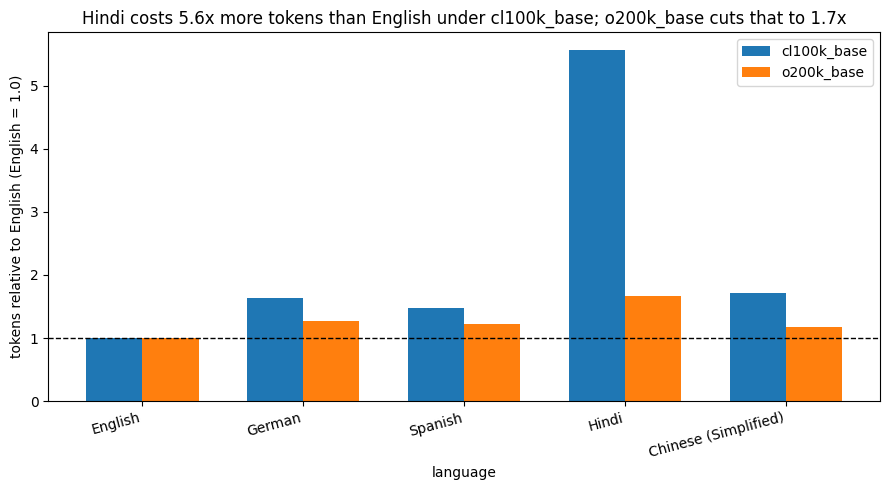

In [23]:
# ---------------------------------------------------------------- Task 5c
# The bar chart.
#
# tokens_vs_english per language, the two encodings side by side, English
# leftmost, a horizontal line at 1.0. Label the axes and give it a title that
# states the finding rather than the variables.

if lang_table is None:
    todo("Task 5c - needs `lang_table` from 5b")
else:
    language_order = ["English"] + [l for l in lang_table["language"] if l != "English"]
    plot_table = lang_table.set_index("language").loc[language_order]

    x = np.arange(len(plot_table))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(x - width / 2, plot_table["cl100k_base_tokens_vs_english"], width, label="cl100k_base")
    ax.bar(x + width / 2, plot_table["o200k_base_tokens_vs_english"], width, label="o200k_base")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_table.index, rotation=15, ha="right")
    ax.set_xlabel("language")
    ax.set_ylabel("tokens relative to English (English = 1.0)")
    ax.set_title("Hindi costs 5.6x more tokens than English under cl100k_base; o200k_base cuts that to 1.7x")
    ax.legend()
    plt.tight_layout()
    plt.show()

In [24]:
# ---------------------------------------------------------------- Task 5d
# Convert the ratios into money.
#
# Fix one support conversation at 2,000 input tokens and 500 output tokens
# FOR AN ENGLISH SPEAKER. Assume the same conversation in another language
# scales by that language's tokens_vs_english ratio from 5b.
#
# Report the per-conversation cost for every language under both encodings,
# and the ratio between the most and least expensive language.

EN_INPUT_TOKENS = 2_000
EN_OUTPUT_TOKENS = 500

conversation_cost = lang_table[["language"]].copy()

for enc_name in ["cl100k_base", "o200k_base"]:
    ratio = lang_table[f"{enc_name}_tokens_vs_english"]
    input_tokens = EN_INPUT_TOKENS * ratio
    output_tokens = EN_OUTPUT_TOKENS * ratio
    cost = (input_tokens / 1_000_000 * RATE_CARD["input_per_mtok"]
            + output_tokens / 1_000_000 * RATE_CARD["output_per_mtok"])

    conversation_cost[f"{enc_name}_input_tokens"] = input_tokens
    conversation_cost[f"{enc_name}_output_tokens"] = output_tokens
    conversation_cost[f"{enc_name}_cost_usd"] = cost

if conversation_cost is None:
    todo("Task 5d - build `conversation_cost`")
else:
    show(conversation_cost, "Task 5d - cost of one support conversation, by language")
    for enc_name in ["cl100k_base", "o200k_base"]:
        costs = conversation_cost[f"{enc_name}_cost_usd"]
        most = conversation_cost.loc[costs.idxmax(), "language"]
        least = conversation_cost.loc[costs.idxmin(), "language"]
        print(f"{enc_name}: most expensive = {most} (${costs.max():.5f}), "
              f"least expensive = {least} (${costs.min():.5f}), "
              f"ratio = {costs.max() / costs.min():.3f}x")


=== Task 5d - cost of one support conversation, by language ===


,language,cl100k_base_input_tokens,cl100k_base_output_tokens,cl100k_base_cost_usd,o200k_base_input_tokens,o200k_base_output_tokens,o200k_base_cost_usd
0,English,2000.000000,500.000000,0.010000,2000.000000,500.000000,0.010000
1,German,3268.849206,817.212302,0.016344,2529.499256,632.374814,0.012647
2,Spanish,2965.277778,741.319444,0.014826,2453.148240,613.287060,0.012266
3,Hindi,11138.888889,2784.722222,0.055694,3339.613287,834.903322,0.016698
4,Chinese (Simplified),3423.611111,855.902778,0.017118,2347.050074,586.762519,0.011735


cl100k_base: most expensive = Hindi ($0.05569), least expensive = English ($0.01000), ratio = 5.569x
o200k_base: most expensive = Hindi ($0.01670), least expensive = English ($0.01000), ratio = 1.670x


### Task 5 — write-up

**TODO (≤200 words).** Name the users who are worst off and quantify how much
worse. State what changed between `cl100k_base` and `o200k_base`, with
numbers. Then answer Product's written question: on this evidence, does "the
same paid plan" deliver the same product to a Hindi-speaking user as to an
English-speaking one?

*Hindi speakers are worst off because under cl100k it cost 11,228 tokens vs 2016 tokens for english which is 5 times more expensive ($0.05569 vs $0.01) o200k is cheaper but it is still more expensive to be Hindi than english as it takes 3368 tokens vs the 2017 tokens in english and costs $0.01670 vs the $0.01 that english costs. It should not be the same paid plan since Hindi takes more tokens than English, so if the same price was offered the Hindi user would have less usage than the English user.*

---

# Task 6 — Recommendation

**TODO (400–600 words).** A memo to the platform lead. Requirements are in
`README.md`, Task 6 — all four points are marked.

Recommend a tokenization approach for each of Projects A, B, and C, each
citing a number you computed above. Name one thing you would measure before
committing and what result would change your mind. Explain one risk created by
tokenizing text one way and feeding it to a model trained on another
tokenizer, and the code-level control that prevents it. Finish by stating what
this analysis does **not** establish.

Prose, not bullets, for at least the opening and closing paragraphs.

---

**MEMO**

To: Platform Lead

From: Data Platform Team

Re: Tokenization decision for Projects A, B, and C



We measured tokenization behavior across the forum archive, a held-out split standing in for next month's posts, and a five-language parallel corpus, rather than relying on intuition about how these tokenizers behave. The findings point to three different recommendations, because the three projects are not solving the same problem.

Project A, Lexical search: 

We recommend the regex tokenizer over raw whitespace splitting, which is built on the full archive vocabulary rather than a capped one. At the full vocabulary, the held out OOV token rate is only ~11.4%, even though the OOV type rate is ~54.7%, meaning most rare types are rare enough that a support agent would rarely need to search for them, so an uncapped index costs little in storage for a large gain in recall. 

Project B, Thread summarization:

At current archive volume, the choice between encodings is about the same: cl100k_base costs $3.23/month vs o200k_base's $3.19/month for the same one pass and 808,286 vs. 797,999 input tokens. We recommend o200k_base anyway, since it is strictly cheaper with no accuracy tradeoff we measured, and because the gap will be larger as we will see below in project C.

Project C, International rollout:

This is where there is a gap. Under cl100k_base, a Hindi speaker's conversation costs 5.57x an English speaker's ($0.0557 vs. $0.0100), and under o200k_base that ratio drops to 1.67x ($0.0167 vs. $0.0100). We recommend o200k_base for the rollout, but note it does not eliminate the disparity, a Hindi speaker still has less usable conversation than an English speaker, it is just more usable that cl100k_base, so yes it will cost the same, but a Hindi user would hit their usage limit quicker.

Before committing, we would want to measure real conversational message length distributions per language, instead of fully accepting on the UDHR's formal declarative register, if casual Hindi support chats compress differently than a legal declaration does than it could change the ratios significantly. 

One concrete risk: text normalized inconsistently before encoding produces silent mismatches café in NFC encodes to 2 tokens under cl100k_base versus 3 tokens in NFD, meaning the same visible string can hash and embed differently depending on which form reached the tokenizer. We could potentially prevent this by enforcing normalize NFC, instead of trusting each downstream service to normalize independently.

Finally, this analysis does not establish translation quality, or anything of the sort, all it measures are token counts and dollar costs, not output quality.

---

## Before you submit

- [x] Kernel restarted and **Run All**, top to bottom, with no errors.
- [x] Every `[ TODO ]` message is gone from the output.
- [x] Every number in your prose appears in a cell output above it.
- [x] The Task 6 memo is 400–600 words.
- [x] Your **AI Usage Report** is written and ready to upload alongside this
      notebook — tool statement, complete logs, validation note. It is
      required even if you used no AI.